In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing.load_data import load_data
from src.preprocessing.clean_data import clean_data
from src.preprocessing.missing_dates import fill_missing_dates
from src.features.feature_engineering import create_features
from src.preprocessing.train_test_split import time_series_split

from src.models.arima_model import train_sarima
from src.models.xgboost_model import train_xgboost

from src.utils.metrics import evaluate_model

In [2]:
df = pd.read_excel(
    r"C:\Users\kondu\Downloads\GenAI-Knowledge-Assistant-main\ds cs\forecasting-system\data\raw\sales_data.xlsx"
)


df = clean_data(df)

df = fill_missing_dates(df)

df = create_features(df)

print(df.head())

          date    state        sales   category         lag_1         lag_7  \
58  2019-03-11  Alabama  112189103.8  Beverages  1.121440e+08  1.118735e+08   
149 2019-06-10  Alabama  129106730.4  Beverages  1.289208e+08  1.278054e+08   
212 2019-08-12  Alabama  108083723.8  Beverages  1.084174e+08  1.104196e+08   
272 2019-10-11  Alabama  110932912.8  Beverages  1.108854e+08  1.106005e+08   
274 2019-10-13  Alabama  123782285.8  Beverages  1.173576e+08  1.106955e+08   

           lag_30  rolling_mean_7  rolling_std_7  day_of_week  month  \
58   1.108365e+08    1.120538e+08   9.739986e+04            0      3   
149  1.235295e+08    1.285490e+08   4.016071e+05            0      6   
212  1.180947e+08    1.090848e+08   7.208712e+05            0      8   
272  1.095083e+08    1.107905e+08   1.025825e+05            4     10   
274  1.096033e+08    1.136185e+08   5.098423e+06            6     10   

     is_holiday  
58            0  
149           0  
212           1  
272           0  
27

In [3]:
train, test = time_series_split(df)

print("Train Shape:", train.shape)

print("Test Shape:", test.shape)

Train Shape: (6432, 12)
Test Shape: (1609, 12)


In [4]:
sarima_model, sarima_preds = train_sarima(
    train,
    test
)

sarima_metrics = evaluate_model(
    test['sales'],
    sarima_preds
)

print("SARIMA Metrics:")

print(sarima_metrics)

SARIMA Metrics:
{'MAE': 606204192.86, 'RMSE': 675131537.49, 'MAPE': 16.79}


In [5]:
xgb_model, xgb_preds = train_xgboost(
    train,
    test
)

xgb_metrics = evaluate_model(
    test['sales'],
    xgb_preds
)

print("XGBoost Metrics:")

print(xgb_metrics)

XGBoost Metrics:
{'MAE': 3686900.91, 'RMSE': 9626798.35, 'MAPE': 0.04}


In [6]:
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost'],
    'MAE': [
        sarima_metrics['MAE'],
        xgb_metrics['MAE']
    ],
    'RMSE': [
        sarima_metrics['RMSE'],
        xgb_metrics['RMSE']
    ],
    'MAPE': [
        sarima_metrics['MAPE'],
        xgb_metrics['MAPE']
    ]
})

comparison_df

,Model,MAE,RMSE,MAPE
0,SARIMA,6.062042e+08,6.751315e+08,16.79
1,XGBoost,3.686901e+06,9.626798e+06,0.04


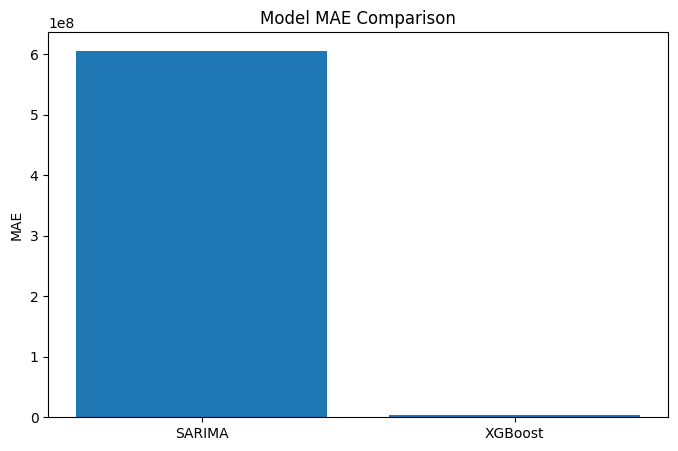

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['MAE']
)

plt.title("Model MAE Comparison")

plt.ylabel("MAE")

plt.show()

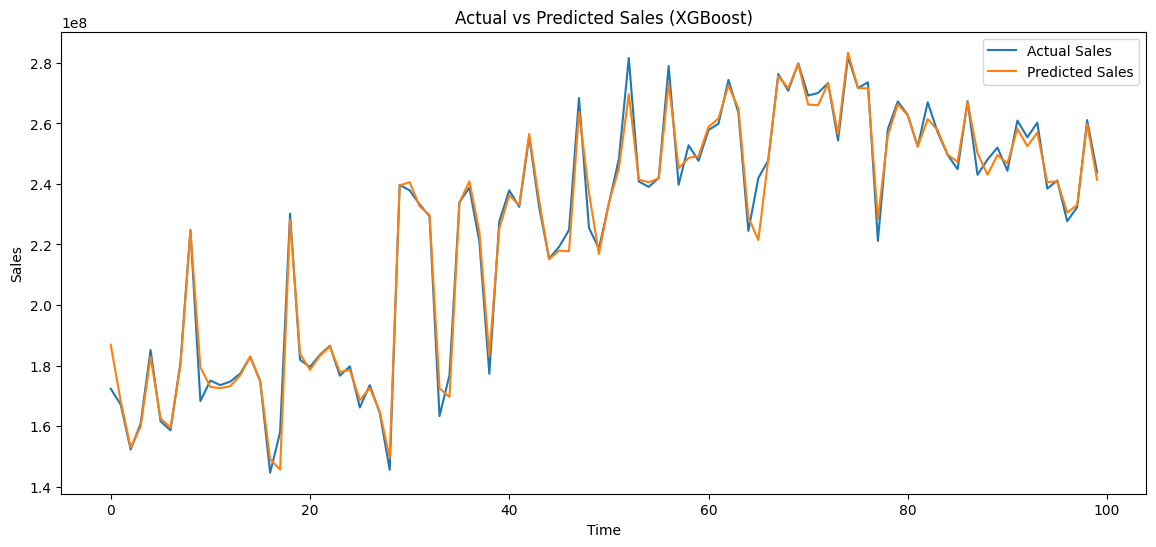

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    test['sales'].values[:100],
    label='Actual Sales'
)

plt.plot(
    xgb_preds[:100],
    label='Predicted Sales'
)

plt.legend()

plt.title("Actual vs Predicted Sales (XGBoost)")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.show()

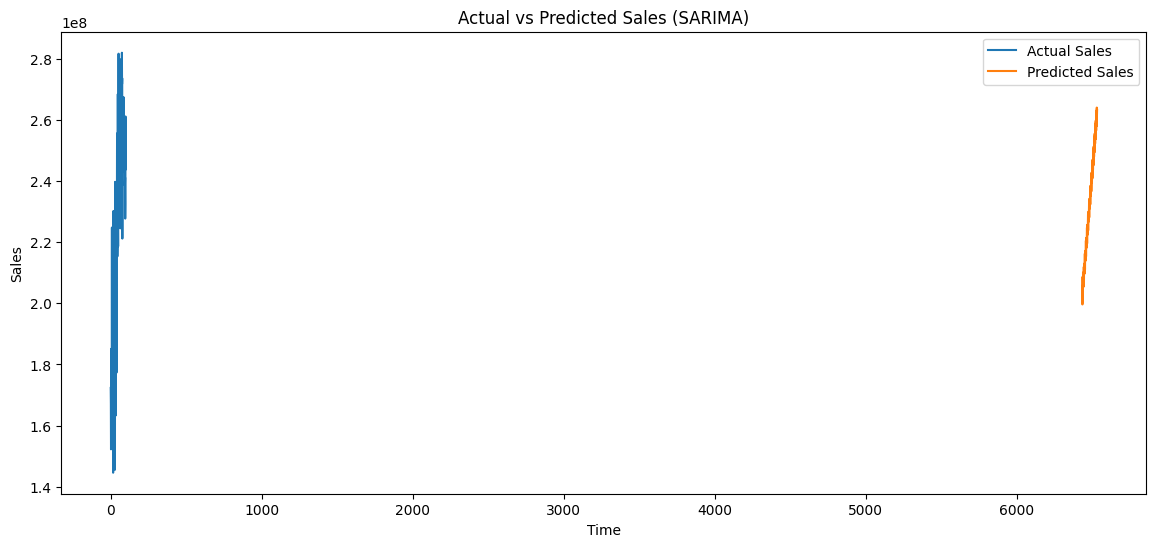

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    test['sales'].values[:100],
    label='Actual Sales'
)

plt.plot(
    sarima_preds[:100],
    label='Predicted Sales'
)

plt.legend()

plt.title("Actual vs Predicted Sales (SARIMA)")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.show()

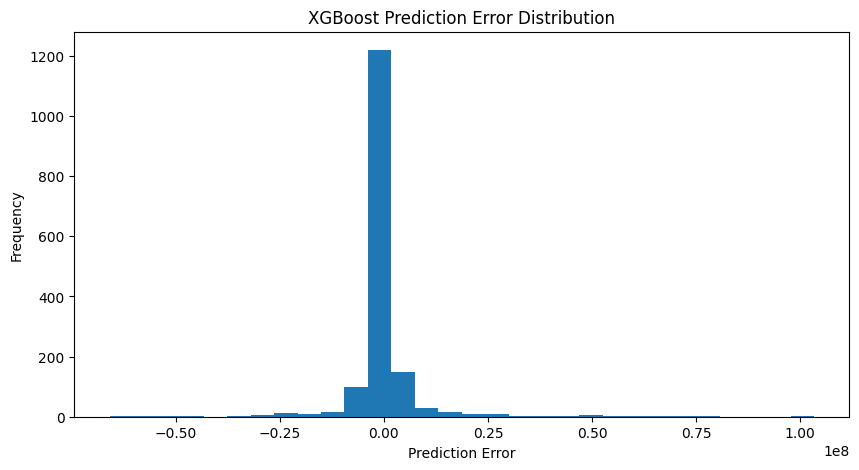

In [11]:
errors = (
    test['sales'].values[:len(xgb_preds)]
    - xgb_preds
)

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("XGBoost Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

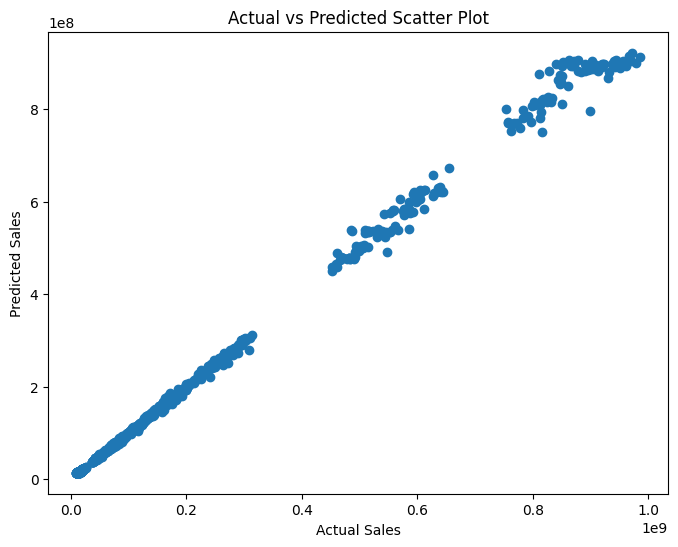

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    test['sales'].values[:len(xgb_preds)],
    xgb_preds
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Scatter Plot")

plt.show()

In [13]:
results = {
    'SARIMA': sarima_metrics['MAE'],
    'XGBoost': xgb_metrics['MAE']
}

best_model = min(
    results,
    key=results.get
)

print("Best Model:", best_model)

Best Model: XGBoost
